In [ ]:
!pip install dexpy

  Preparing metadata (setup.py) ... done
  Created wheel for dexpy: filename=dexpy-0.12-py3-none-any.whl size=30218 sha256=250d7c71c270a57391e5025fb52cab32105c4ee6c6918969eea9b702c4896cfd
  Stored in directory: /root/.cache/pip/wheels/dd/8a/9e/c664d82eab1605d51db7f16b30ee38d1712f54cd2106b0c79e
Successfully built dexpy


In [ ]:
import dexpy.factorial
import dexpy.optimal
from dexpy.model import ModelOrder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

#TASK A

##TASK A1

In [ ]:
coffee_design = dexpy.factorial.build_factorial(5, 2**(5-1))  # changed to 2**(5-2) to achieve a pure 2**(5-2) for task (i)
coffee_design.columns = ['amount', 'grind_size', 'brew_time', 'grind_type', 'beans']

center_points = [[0, 0, 0, -1, -1],
                 [0, 0, 0, -1, 1],
                 [0, 0, 0, 1, -1],
                 [0, 0, 0, 1, 1]]
# center_points
temp = pd.DataFrame(center_points*2, columns=coffee_design.columns)
coffee_design = pd.concat([coffee_design, temp], ignore_index=True)
coffee_design.index = np.arange(0, len(coffee_design))
print(coffee_design)
print()

actual_lows = {'amount':2.5,
               'grind_size':8,
               'brew_time':3.5,
               'grind_type':'burr',
               'beans':'light'}

actual_highs = {'amount':4,
               'grind_size':10,
               'brew_time':4.5,
               'grind_type':'blade',
               'beans':'dark'}

actual_design = dexpy.design.coded_to_actual(coffee_design, actual_lows, actual_highs)
actual_design

# (i)
# 8 experiments

# (ii)
# 24

    amount  grind_size  brew_time  grind_type  beans
0       -1          -1         -1          -1      1
1       -1          -1         -1           1     -1
2       -1          -1          1          -1     -1
3       -1          -1          1           1      1
4       -1           1         -1          -1     -1
5       -1           1         -1           1      1
6       -1           1          1          -1      1
7       -1           1          1           1     -1
8        1          -1         -1          -1     -1
9        1          -1         -1           1      1
10       1          -1          1          -1      1
11       1          -1          1           1     -1
12       1           1         -1          -1      1
13       1           1         -1           1     -1
14       1           1          1          -1     -1
15       1           1          1           1      1
16       0           0          0          -1     -1
17       0           0          0          -1 

,amount,grind_size,brew_time,grind_type,beans
0,2.50,8.0,3.5,burr,dark
1,2.50,8.0,3.5,blade,light
2,2.50,8.0,4.5,burr,light
3,2.50,8.0,4.5,blade,dark
4,2.50,10.0,3.5,burr,light
5,2.50,10.0,3.5,blade,dark
6,2.50,10.0,4.5,burr,dark
7,2.50,10.0,4.5,blade,light
8,4.00,8.0,3.5,burr,light
9,4.00,8.0,3.5,blade,dark


## TASK A2

In [ ]:
coffee_design['taste_rating'] = [
    4.4, 2.6, 2.4, 8.6, 1.6, 2.8,
    7.2, 3.4, 6.8, 3.4, 3.8, 9.0,
    5.2, 3.6, 8.2, 7.0, 5.4, 6.8,
    3.6, 5.4, 4.8, 6.2, 4.4, 5.8
]

coffee_design.index = np.arange(0, len(coffee_design))
actual_design = dexpy.design.coded_to_actual(coffee_design, actual_lows, actual_highs)

actual_design

,amount,grind_size,brew_time,grind_type,beans,taste_rating
0,2.50,8.0,3.5,burr,dark,4.4
1,2.50,8.0,3.5,blade,light,2.6
2,2.50,8.0,4.5,burr,light,2.4
3,2.50,8.0,4.5,blade,dark,8.6
4,2.50,10.0,3.5,burr,light,1.6
5,2.50,10.0,3.5,blade,dark,2.8
6,2.50,10.0,4.5,burr,dark,7.2
7,2.50,10.0,4.5,blade,light,3.4
8,4.00,8.0,3.5,burr,light,6.8
9,4.00,8.0,3.5,blade,dark,3.4


## TASK A3

In [ ]:
coffee_design_as_np_array = coffee_design.to_numpy()
y_np = coffee_design_as_np_array[:,5]
y_np = y_np.reshape((-1,1))
X_np = coffee_design_as_np_array[:,0:5]

shapeX = X_np.shape
nrows = shapeX[0]
Z = np.c_[np.ones((nrows,1)),X_np]

Z_transposed = np.transpose(Z)
Z_transposed_Z = np.matmul(Z_transposed,Z)
Z_transposed_Z_inv = np.linalg.inv(Z_transposed_Z)
w_np = np.matmul(Z_transposed_Z_inv, np.matmul(Z_transposed, y_np))
print(w_np)
print(w_np.shape)

[[ 5.1       ]
 [ 0.875     ]
 [-0.125     ]
 [ 1.2       ]
 [-0.13333333]
 [ 0.45      ]]
(6, 1)


## TASK A4

(i)

The main effect which is the largest is w_3 that is 1.2


---


(ii)

So the model can recognize the scale of the different types and make its conclusion from it. When using scales it has to do more calculations when [-1, 1] is the same. They're able to be directly compared to one another, they have the same scale.

## TASK A5

In [ ]:
Z_np = np.c_[np.ones((nrows, 1)), X_np]
print(X_np.shape[1])
for ii in range(X_np.shape[1]):
    for jj in range(ii+1, X_np.shape[1]):
        Z_np = np.c_[Z_np, X_np[:,ii]*X_np[:,jj]]
# print(Z_np.shape)

Z_transposed = np.transpose(Z_np)
Z_transposed_Z = np.matmul(Z_transposed, Z_np)
Z_transposed_Z_inv = np.linalg.inv(Z_transposed_Z)
w_np = np.matmul(Z_transposed_Z_inv, np.matmul(Z_transposed, y_np))
# print(w_np)
print(f"w_0, base effect:\n{w_np[0]}\n")
print(f'w_1 -> w_5, main effects:\n{w_np[1:6]}\n')
print(f'w_12 -> w_45, interaction effects:\n{w_np[6:]}\n')
print(w_np.shape)

5
w_0, base effect:
[5.1]

w_1 -> w_5, main effects:
[[ 0.875     ]
 [-0.125     ]
 [ 1.2       ]
 [-0.13333333]
 [ 0.45      ]]

w_12 -> w_45, interaction effects:
[[ 0.25      ]
 [-0.075     ]
 [-0.175     ]
 [-1.325     ]
 [ 0.375     ]
 [-0.725     ]
 [ 0.375     ]
 [ 0.75      ]
 [ 0.15      ]
 [ 0.08333333]]

(16, 1)


(i)

Top 3 most influential interaction weights are:
w_15, w_34 and w_24

* 1_2 : [ 0.25      ]
* 1_3 : [-0.075     ]
* 1_4 : [-0.175     ]
* 1_5 : [-1.325     ]
* 2_3 : [ 0.375     ]
* 2_4 : [-0.725     ]
* 2_5 : [ 0.375     ]
* 3_4 : [ 0.75      ]
* 3_5 : [ 0.15      ]
* 4_5 : [ 0.08333333]

2 and 4 are positive almost all of the time except when it's w_24


---


(ii)

Interaction weights are based on variables that are based on other variables.

w_34 is large which means that x_3 effect on y changes based on x_4

# TASK B

In [ ]:
n_factors = 2
reaction_design = dexpy.optimal.build_optimal(n_factors, run_count=6, order=ModelOrder.quadratic)

column_names = ['time', 'temp']
actual_lows = {'time':40, 'temp':80}
actual_highs = {'time':50, 'temp':90}
reaction_design.columns = column_names
reaction_design = dexpy.design.coded_to_actual(reaction_design, actual_lows, actual_highs)
print(reaction_design)

        time       temp
0  50.000000  82.727273
1  46.363636  80.000000
2  40.000000  80.000000
3  40.000000  90.000000
4  44.545455  85.454545
5  50.000000  90.000000


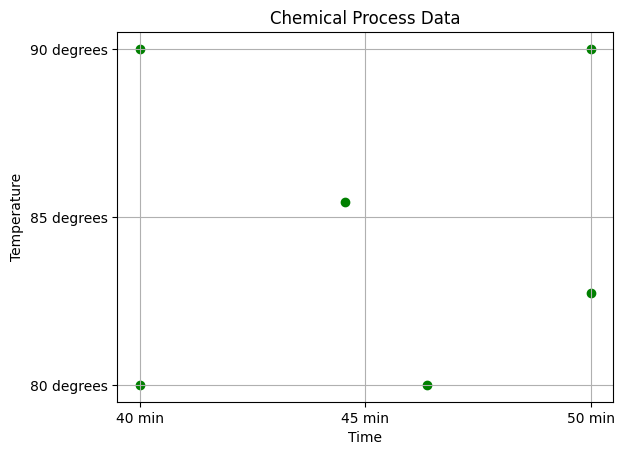

In [ ]:
reaction_design_np = reaction_design.to_numpy()
fig = plt.figure()
ax = fig.add_subplot()

plt.scatter(reaction_design_np[:,0], reaction_design_np[:,1], color="green", marker="o")
plt.xlabel("Time")
plt.ylabel("Temperature")
ax.set_xticks([40, 45, 50])
ax.set_xticklabels(['40 min', '45 min', '50 min'])
ax.set_yticks([80, 85, 90])
ax.set_yticklabels(['80 degrees', '85 degrees', '90 degrees'])
ax.grid()
plt.title("Chemical Process Data")
plt.show()

## TASK B1

### (i)

In [ ]:
def modelbuilder(n_experiments):
    n_factors = 2
    reaction_design = dexpy.optimal.build_optimal(n_factors, run_count=n_experiments, order=ModelOrder.quadratic)

    column_names = ['time', 'temp']
    actual_lows = {'time':40, 'temp':80}
    actual_highs = {'time':50, 'temp':90}

    reaction_design.columns = column_names
    actual_design = dexpy.design.coded_to_actual(reaction_design, actual_lows, actual_highs)
    return actual_design, reaction_design

actual_design, reaction_design = modelbuilder(6)
print(actual_design.to_string(index=False))

     time      temp
50.000000 80.000000
40.000000 80.000000
40.000000 90.000000
40.000000 84.545455
44.545455 80.000000
50.000000 90.000000


### (ii)

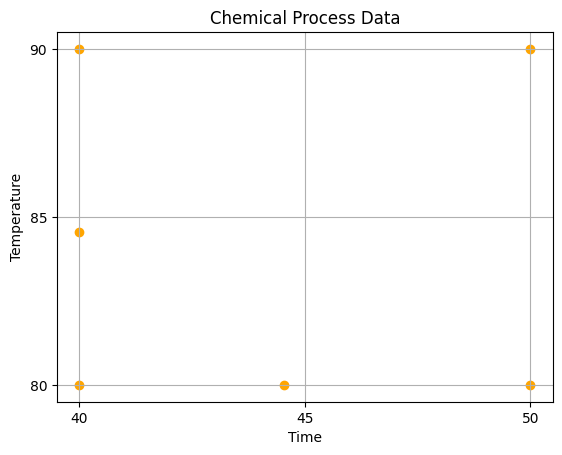

In [ ]:
actual_design_np = actual_design.to_numpy()
reaction_design_np = reaction_design.to_numpy()

def plot_design(design_np):
    plt.figure()
    plt.scatter(design_np[:,0], design_np[:,1], color="orange", marker="o")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.xticks([40, 45, 50])
    plt.yticks([80, 85, 90])
    plt.grid()
    plt.title("Chemical Process Data")
    plt.show()
    pass

plot_design(actual_design_np)

### (iii)

In [ ]:
X_np = reaction_design_np
shapeX = X_np.shape
nrows = shapeX[0]

Z_np = np.c_[np.ones((nrows, 1)), X_np]
Z_np = np.c_[Z_np, X_np[:,0] * X_np[:,0]]
Z_np = np.c_[Z_np, X_np[:,1] * X_np[:,1]]
Z_np = np.c_[Z_np, X_np[:,0] * X_np[:,1]]

det_Z_np = np.linalg.det(np.matmul(np.transpose(Z_np), Z_np))
print(f"|(Z^T Z)| for optimal design: {det_Z_np}\n")

|(Z^T Z)| for optimal design: 247.64152412234364



### (iv)

     time      temp
50.000000 90.000000
45.454545 85.454545
50.000000 90.000000
40.000000 80.000000
50.000000 80.000000
50.000000 84.545455
40.000000 90.000000
44.545455 80.000000
40.000000 84.545455
44.545455 90.000000


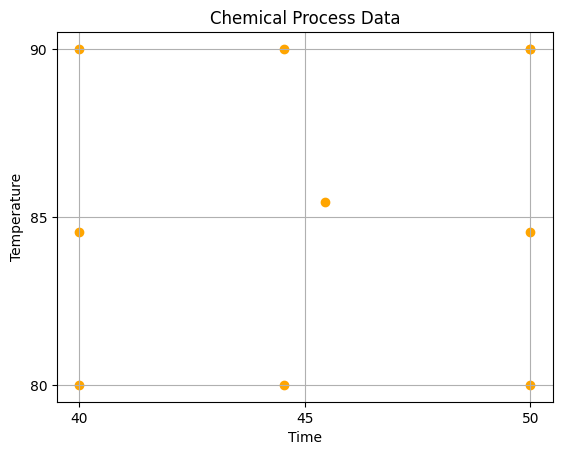

In [ ]:
actual_design, reaction_design = modelbuilder(10)

actual_design_np = actual_design.to_numpy()
reaction_design_np = reaction_design.to_numpy()

print(actual_design.to_string(index=False))
plot_design(actual_design_np)

### (v)

In [ ]:
duplicates = actual_design.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 1


## TASK B2

In [ ]:
X =[[-1 ,-1], [1 ,-1], [-1, 1], [1, 1], [0, 0], [0, 0], [0, 0], [1, 0], [-1, 0], [0, 1], [0, -1]]
actual_y = np.array([13.65, 13.74, 15.48, 13.53, 17.38, 16.35, 16.41, 12.51, 15.17, 14.86, 11.85])
log_y = np.log(actual_y)

X = np.asarray(X)
log_y = np.asarray(log_y).reshape((-1,1))
# print(X)
# print(log_y)

nrows = X.shape[0]

# Intercept column
Z = np.c_[np.ones((nrows, 1)), X]

# Quadratic and interaction terms
Z = np.c_[Z, X[:,0] * X[:,1]]
Z = np.c_[Z, X[:,0] * X[:,0]]
Z = np.c_[Z, X[:,1] * X[:,1]]

Z_transpose = np.transpose(Z)
Z_transpose_Z = np.matmul(Z_transpose, Z)
Z_transpose_Z_inv = np.linalg.inv(Z_transpose_Z)
w = np.matmul(Z_transpose_Z_inv, np.matmul(np.transpose(Z), log_y))

print(f"w_0: {w[0][0]:10.5f}")
print(f"w_1: {w[1][0]:10.5f}")
print(f"w_2: {w[2][0]:10.5f}")
print(f"w_12: {w[3][0]:9.5f}")
print(f"w_11: {w[4][0]:9.5f}")
print(f"w_22: {w[5][0]:9.5f}")

[[ 1. -1. -1.]
 [ 1.  1. -1.]
 [ 1. -1.  1.]
 [ 1.  1.  1.]
 [ 1.  0.  0.]
 [ 1.  0.  0.]
 [ 1.  0.  0.]
 [ 1.  1.  0.]
 [ 1. -1.  0.]
 [ 1.  0.  1.]
 [ 1.  0. -1.]]
[[-1 -1]
 [ 1 -1]
 [-1  1]
 [ 1  1]
 [ 0  0]
 [ 0  0]
 [ 0  0]
 [ 1  0]
 [-1  0]
 [ 0  1]
 [ 0 -1]]
[[ 1. -1. -1.  1.  1.  1.]
 [ 1.  1. -1. -1.  1.  1.]
 [ 1. -1.  1. -1.  1.  1.]
 [ 1.  1.  1.  1.  1.  1.]
 [ 1.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  0.]
 [ 1.  1.  0.  0.  1.  0.]
 [ 1. -1.  0.  0.  1.  0.]
 [ 1.  0.  1.  0.  0.  1.]
 [ 1.  0. -1.  0.  0.  1.]]
[[-1 -1]
 [ 1 -1]
 [-1  1]
 [ 1  1]
 [ 0  0]
 [ 0  0]
 [ 0  0]
 [ 1  0]
 [-1  0]
 [ 0  1]
 [ 0 -1]]
w_0:    2.76276
w_1:   -0.05348
w_2:    0.05613
w_12:  -0.03530
w_11:  -0.06025
w_22:  -0.09767


## TASK B3

In [ ]:
##### step 1 #####
design_B3 = dexpy.optimal.build_optimal(2, run_count=6, order=ModelOrder.quadratic)
X = design_B3.to_numpy()

shapeX = X.shape
nrows = shapeX[0]

Z = np.c_[np.ones((nrows, 1)), X]
Z = np.c_[Z, X[:,0] * X[:,0]]
Z = np.c_[Z, X[:,1] * X[:,1]]
Z = np.c_[Z, X[:,0] * X[:,1]]

det_Z = np.linalg.det(np.matmul(np.transpose(Z), Z))
# print(f"D-optimal matrix: {det_Z}\n")



##### step 2 #####

x1 = X[:,0]
x2 = X[:,1]

noise = np.random.normal(0, 0.1, size=nrows)

log_y_prediction = (w[0] +
                    w[1] * x1 +
                    w[2] * x2 +
                    w[3] * x1 * x2 +
                    w[4] * x1 * x1 +
                    w[5] * x2 * x2 +
                    noise)
# print(log_y_prediction)


##### step 3 #####
v_D_optimal = np.linalg.inv(Z.T @ Z) @ (Z.T @ log_y_prediction)



##### step 4 #####
w_t = w.reshape((1,-1))[0]
print(f"Predicted: {v_D_optimal}")
print(f"True:      {w_t}")
print(f"MSE:       {np.mean((w_t - v_D_optimal)**2)}")
print(f"R2:        {r2_score(w_t, v_D_optimal)}")

Predicted: [ 2.7056993  -0.08564212  0.00292737 -0.01098925 -0.11905241  0.02979408]
True:      [ 2.76275703 -0.05347652  0.05612545 -0.0353028  -0.06024905 -0.09767266]
MSE:       0.004569499682191569
R2:        0.995814560535777
